# A4 — Estudo de caso: triagem de COVID-19 em raio-X com augmentation sintética por cGAN

**Como executar:** Google Colab com GPU T4 (*Ambiente de execução > Alterar o tipo de ambiente de
execução > T4 GPU*) e *Executar tudo*. A 4.2 (tráfego urbano) é só discussão escrita, no fim.

| | Execução completa |
|---|---|
| Tempo estimado de execução | [preencher após a execução final] |
| Pico de VRAM alocada (reservada) | [preencher] |
| Pico de RAM do processo | [preencher] |

> [Data e forma da medição, como na A1–A3.]

## Setup

Clone do código (`src/`), pasta de saída, imports e configuração. O código dos módulos está no
repositório; o notebook só orquestra.

In [1]:
import os
import subprocess
import time

_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R15)
TEMPOS = []  # registro das etapas cronometradas

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A4_estudo_caso_raio_x"
REPO_DIR = "/content/repo"
# Versão do código: na entrega, a tag da A4 (ex.: "a4-entrega"). None = branch principal.
GIT_REF = None

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none + --sparse: baixa só os arquivos da pasta da A4, não o repositório inteiro
    ref = ["--branch", GIT_REF] if GIT_REF else []
    subprocess.run(["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", *ref, REPO_URL, REPO_DIR],
                   check=True)
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
else:
    # Já clonado nesta sessão (talvez por outro notebook): garante a pasta da A4 no sparse checkout
    subprocess.run(["git", "sparse-checkout", "add", SUBPASTA], cwd=REPO_DIR, check=True)
    if GIT_REF:
        # Garante a versão fixada (não puxa commits novos)
        subprocess.run(["git", "fetch", "--depth", "1", "origin", "tag", GIT_REF], cwd=REPO_DIR, check=True)
        subprocess.run(["git", "checkout", GIT_REF], cwd=REPO_DIR, check=True)
    else:
        print(f"Repositório já clonado em '{REPO_DIR}': buscando mudanças mais recentes...")
        subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1)})

In [2]:
import importlib, sys

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Ao reexecutar o notebook na mesma sessão depois de atualizar o código, recarrega os módulos src.*
# já importados. Num runtime novo não há nada para recarregar e a célula não faz nada.
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])

In [3]:
# Onde salvar os artefatos desta execução (split, checkpoints da GAN e dos classificadores, tabelas, figuras).
# * False (padrão): disco local do Colab, em /content (apagado quando o runtime é desconectado).
# * True: Google Drive (pede autorização no início).
from pathlib import Path

SALVAR_NO_DRIVE = False

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A4_estudo_caso_raio_x")
else:
    BASE_DIR = Path("/content/A4_estudo_caso_raio_x_saida")

DIR_DADOS = BASE_DIR / "data"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"   # tabelas e figuras que vão para o relatório

for d in (DIR_DADOS, DIR_REPORT_ASSETS):
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

BASE_DIR = /content/A4_estudo_caso_raio_x_saida (Drive: False)


In [ ]:
# Configuração do experimento (cada escolha é justificada nos markdowns das seções)
SEED = 42
CLASSES = ["Normal", "Viral Pneumonia", "COVID"]   # Lung Opacity fica fora (não faz parte do caso)
# Escassez do projeto legado só no TREINO (840 / 240 / 120 = 70% / 20% / 10%); validação e teste reais,
# maiores, sorteados do restante. O teste com 300 COVID faz cada erro valer ~0,3 ponto de recall.
N_TREINO = {"Normal": 840, "Viral Pneumonia": 240, "COVID": 120}
N_VALIDACAO = {"Normal": 300, "Viral Pneumonia": 150, "COVID": 150}
N_TESTE = {"Normal": 600, "Viral Pneumonia": 300, "COVID": 300}
SEEDS_CLASSIFICADOR = [0, 1, 2]   # 3 treinos por condição

# Quase-duplicatas (mesma foto recomprimida/redimensionada): limiar na correlação dos pixels em 64×64,
# fixado por inspeção visual das figuras da seção de quase-duplicatas (antes de qualquer treino)
LIMIAR_QUASE_DUPLICATA = 0.97   # confirmado na inspeção visual (06/10): >= 0,97 = mesma foto

# Condições do classificador (mesma configuração, só os dados de treino mudam):
# * "sem_tratamento": as 1.200 imagens reais (840/240/120), como no legado;
# * "oversampling": as 120 COVID reais repetidas até 120 + N_SINTETICAS (controle: mais peso para COVID,
#   sem imagens novas);
# * "gan": as 120 COVID reais + N_SINTETICAS geradas pela cGAN.
N_SINTETICAS = 720   # COVID passa de 120 para 840, o mesmo número de Normal
CONFIG_CLASSIFICADOR = {
    "resolucao": 224, "tamanho_lote": 32, "epocas": 12, "lr": 1e-4, "weight_decay": 1e-4,
    "criterio": "recall_medio",   # seleção da época pela média dos recalls por classe na validação
    "num_workers": 2,
}

# Teste confirmatório (decidido em 06/10/2026, depois de uma avaliação exploratória das condições sem GAN no
# teste original): sorteado do restante, nunca visto; é ele que dá o número final das 3 condições
SEED_TESTE_CONFIRMATORIO = SEED + 1
VERSAO_PREDICOES = "v2"   # v2: oversampling determinístico (cada COVID real × 7) e predições no teste confirmatório

# cGAN (DCGAN condicional 128×128). Regra fixada ANTES do treino: usa-se a versão COM mitigação, no checkpoint
# da última época; a versão sem mitigação existe só para o diagnóstico de instabilidade (R6, R7)
CONFIG_GAN = {
    "lado": 128, "dim_z": 128, "base": 64, "tamanho_lote": 64, "epocas": 200,
    "lr": 2e-4,                                        # sem mitigação: mesmo lr para D e G
    "lr_d_mitigacao": 4e-4, "lr_g_mitigacao": 1e-4,    # com mitigação: TTUR (D mais rápido que G)
    "num_workers": 0,                                  # dataset já em memória
    "monitorar_a_cada": 25,                            # épocas entre as medições de diversidade/memorização
}
SEED_GAN = 0

## 4.1 — Diagnóstico do projeto legado (R1, R2)

**O projeto:** 1.200 raio-X de tórax em 3 classes (Normal 840, Pneumonia 240, COVID-19 120); split 80/20
sem estratificação; ResNet-18 sem pré-treino; SGD com learning rate fixo de 0,01 por 15 épocas; sem
augmentation; avaliação só pela accuracy global. Resultado: 93% de accuracy no treino e 61% na validação,
e o time clínico relata que o modelo "ignora casos positivos".

**Um número resume o problema:** um modelo que respondesse sempre "Normal" teria **70% de accuracy**
(840/1.200), mais do que os 61% do modelo legado, e recall zero de COVID-19. Ou seja, o modelo é pior que
o trivial na métrica que o próprio projeto escolheu, e essa métrica nem enxerga o erro que importa.

Em triagem, o erro mais caro é o **falso negativo**: um paciente com COVID-19 classificado como Normal
deixa de ser isolado e tratado. O falso positivo custa um exame confirmatório (RT-PCR). Por isso, o impacto
clínico de cada problema abaixo é medido principalmente pelo que ele faz com a **sensibilidade (recall)
de COVID-19**.

| # | Problema técnico | Evidência no projeto | Impacto clínico esperado |
|---|---|---|---|
| 1 | **Desbalanceamento severo sem tratamento** (70% / 20% / 10%): sem pesos de classe, sem oversampling, sem ajuste de limiar | 120 COVID-19 contra 840 Normal; a cross-entropy padrão é dominada pela classe Normal | O modelo aprende que responder "Normal" minimiza a perda: **falsos negativos de COVID-19** (o "ignora casos positivos" relatado), com pacientes infectados liberados sem isolamento nem tratamento |
| 2 | **Métrica inadequada: só accuracy global** | 61% de validação, abaixo do baseline "sempre Normal" (70%); nenhum recall por classe | O problema do item 1 fica **invisível** para a equipe: o modelo poderia ser adotado sem que ninguém soubesse quantos casos de COVID-19 ele perde. Em triagem, a métrica principal deveria ser o recall (sensibilidade) de COVID-19, com a especificidade ao lado |
| 3 | **Split 80/20 sem estratificação e sem conjunto de teste** | Na validação, ~24 imagens de COVID-19 esperadas, podendo ser bem menos; a mesma validação escolhe o modelo e mede o desempenho | Uma estimativa de desempenho **instável e otimista**: com ~24 casos, cada erro muda o recall em ~4 pontos, e o número reportado não representa o que acontecerá com pacientes novos. Também não há garantia de separação por paciente (várias imagens do mesmo paciente em treino e validação inflariam o resultado) |
| 4 | **ResNet-18 sem pré-treino** (~11 milhões de parâmetros) para ~960 imagens de treino | Gap de **93% × 61%** entre treino e validação: overfitting | O modelo memoriza as imagens de treino em vez de aprender padrões de doença, e **falha em pacientes novos**. O pré-treino (ImageNet ou, melhor, em raio-X) daria features genéricas de bordas e texturas com muito menos dados |
| 5 | **Sem data augmentation** | Só 96 imagens de COVID-19 no treino (80% de 120), todas vistas da mesma forma a cada época | Reforça o overfitting do item 4 e torna o modelo **frágil a variações reais** (posição do paciente, contraste, equipamento), justamente na classe com menos exemplos |
| 6 | **Otimização sem controle**: SGD com lr fixo de 0,01, 15 épocas, sem scheduler, sem early stopping e sem seleção do melhor modelo pela validação | O modelo entregue é o da última época, seja ela boa ou não | Resultado **arbitrário e não reprodutível**: outro treino pode dar outro modelo; sem um checkpoint escolhido por um critério clínico (recall na validação), não há como garantir o desempenho do que é implantado |
| 7 | **Risco de atalhos (shortcut learning) e viés de fonte** | Em bases públicas, as imagens de COVID-19 costumam vir de hospitais e equipamentos diferentes das demais (marcações, bordas, contraste) | O modelo pode aprender **a fonte da imagem, e não a doença**, e falhar ao ser usado em outro hospital: os falsos negativos aparecem justamente onde o sistema seria implantado |
| 8 | **Sem limiar de decisão nem calibração** | Decisão por argmax, sem ajustar o limiar da classe COVID-19 | Em triagem, o limiar deveria ser escolhido para atingir uma sensibilidade alvo (ex.: ≥ 95%), aceitando mais falsos positivos. Sem isso, o equilíbrio entre falso negativo e falso positivo é decidido pelo acaso do treino, e não por critério clínico |

Os problemas se reforçam: o desbalanceamento (1) e a ausência de augmentation (5) levam o modelo a
ignorar COVID-19; o modelo sem pré-treino (4) e a otimização sem controle (6) causam o overfitting; e a
métrica (2) e o split (3) impedem que qualquer um desses problemas seja percebido antes da implantação. O
plano de melhoria (R11, R12) trata cada um deles.

## Dados: COVID-19 Radiography Database (Kaggle)

[Origem, versão, licença e citação; estrutura; quantas imagens por classe; o que fica de fora.]

In [5]:
import kagglehub

from src.dados import ASSINATURA_DATASET, N_ARQUIVOS_DATASET, VERSAO_DATASET, impressao_digital

# Download com a versão fixada. No Colab, o kagglehub pode servir o cache do próprio Colab
# (/kaggle/input/...), cujo caminho não mostra a versão: quem garante que os dados são os mesmos é a
# impressão digital (nº de arquivos + hash da lista caminho|tamanho).
_t0 = time.perf_counter()
DIR_DATASET = Path(kagglehub.dataset_download(
    f"tawsifurrahman/covid19-radiography-database/versions/{VERSAO_DATASET}"))
TEMPOS.append({"etapa": "download do dataset", "segundos": round(time.perf_counter() - _t0, 1)})
print(DIR_DATASET)

n_arquivos, mb, assinatura = impressao_digital(DIR_DATASET)
assert (n_arquivos, assinatura) == (N_ARQUIVOS_DATASET, ASSINATURA_DATASET), "O conteúdo do dataset mudou"
print(f"{n_arquivos} arquivos, {mb} MB, assinatura {assinatura}")

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
/kaggle/input/covid19-radiography-database
42335 arquivos, 806.8 MB, assinatura 81edf2e3981be9c4


In [6]:
from collections import Counter

import pandas as pd

from src.dados import PASTA_RAIZ, arvore, carregar_imagem, ler_metadados, listar_imagens, remover_duplicatas

arvore(DIR_DATASET)
print("Extensões:", Counter(p.suffix.lower() for p in DIR_DATASET.rglob("*") if p.is_file()).most_common())

# Imagens das 3 classes do caso (as máscaras de pulmão e a classe Lung Opacity não são usadas)
imagens_brutas = listar_imagens(DIR_DATASET, CLASSES)
print(f"{len(imagens_brutas)} imagens:", imagens_brutas["classe"].value_counts().reindex(CLASSES).to_dict())

# Fonte de cada imagem (URL dos metadados de cada classe)
metadados = ler_metadados(DIR_DATASET, CLASSES)
n_antes = len(imagens_brutas)
imagens_brutas = imagens_brutas.merge(metadados[["classe", "nome", "url", "fonte"]], on=["classe", "nome"], how="left")
assert len(imagens_brutas) == n_antes, "nome repetido nos metadados duplicou linhas no merge"
sem_fonte = imagens_brutas["fonte"].isna().sum()
print(f"Imagens sem linha nos metadados: {sem_fonte}")

# Duplicatas exatas (md5): mesma classe -> fica a primeira; classes diferentes -> conflito, saem todas.
# Feito ANTES do split, para uma cópia não cair no treino e a outra no teste.
imagens, duplicadas, conflitos = remover_duplicatas(imagens_brutas)
print(f"Duplicatas exatas: {len(duplicadas)} arquivos em {duplicadas['md5'].nunique()} grupos; "
      f"conflitos de classe: {len(conflitos)}")
if len(duplicadas):
    display(duplicadas.groupby("md5").agg(classe=("classe", "first"), arquivos=("arquivo", list)).reset_index(drop=True).head(20))
imagens["caminho"] = [str(DIR_DATASET / c) for c in imagens["caminho_rel"]]
print(f"Imagens após remover duplicatas: {len(imagens)}")

COVID-19_Radiography_Dataset/  (42335 arquivos)
    COVID/  (7232 arquivos)
        images/  (3616 arquivos)
        masks/  (3616 arquivos)
    Lung_Opacity/  (12024 arquivos)
        images/  (6012 arquivos)
        masks/  (6012 arquivos)
    Normal/  (20384 arquivos)
        images/  (10192 arquivos)
        masks/  (10192 arquivos)
    Viral Pneumonia/  (2690 arquivos)
        images/  (1345 arquivos)
        masks/  (1345 arquivos)
Extensões: [('.png', 42330), ('.xlsx', 4), ('.txt', 1)]
15153 imagens: {'Normal': 10192, 'Viral Pneumonia': 1345, 'COVID': 3616}
Imagens sem linha nos metadados: 0
Duplicatas exatas: 96 arquivos em 42 grupos; conflitos de classe: 0


,classe,arquivos
0,COVID,"[COVID-2416.png, COVID-2418.png]"
1,COVID,"[COVID-2084.png, COVID-2085.png]"
2,COVID,"[COVID-3298.png, COVID-3299.png]"
3,COVID,"[COVID-3488.png, COVID-3489.png]"
4,COVID,"[COVID-277.png, COVID-280.png]"
5,Viral Pneumonia,"[Viral Pneumonia-74.png, Viral Pneumonia-75.png]"
6,COVID,"[COVID-2458.png, COVID-2459.png]"
7,COVID,"[COVID-2492.png, COVID-2493.png]"
8,COVID,"[COVID-2666.png, COVID-2667.png]"
9,COVID,"[COVID-2941.png, COVID-2942.png]"


Imagens após remover duplicatas: 15099


Imagens por classe: {'Normal': 10191, 'Viral Pneumonia': 1338, 'COVID': 3570}
Tamanho (px) e modo de cor por classe:


,largura_min,largura_max,altura_min,altura_max,modos
classe,,,,,
Normal,299,299,299,299,{'L': 10191}
Viral Pneumonia,299,299,299,299,"{'L': 1198, 'RGB': 140}"
COVID,299,299,299,299,{'L': 3570}


classe,Normal,Viral Pneumonia,COVID
fonte,,,
bimcv.cipf.es,0,0,2433
eurorad.org,0,0,257
github.com,0,0,763
kaggle.com/c/rsna-pneumonia-detection-challenge,8850,0,0
kaggle.com/paultimothymooney/chest-xray-pneumonia,1341,1338,0
sirm.org,0,0,117


Imagens RGB: 140 ({'Viral Pneumonia': 140}); diferença máxima entre canais: 0 em 140, > 0 em 0 (máx. 0)


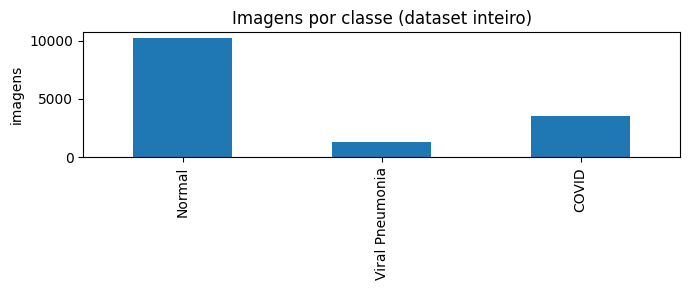

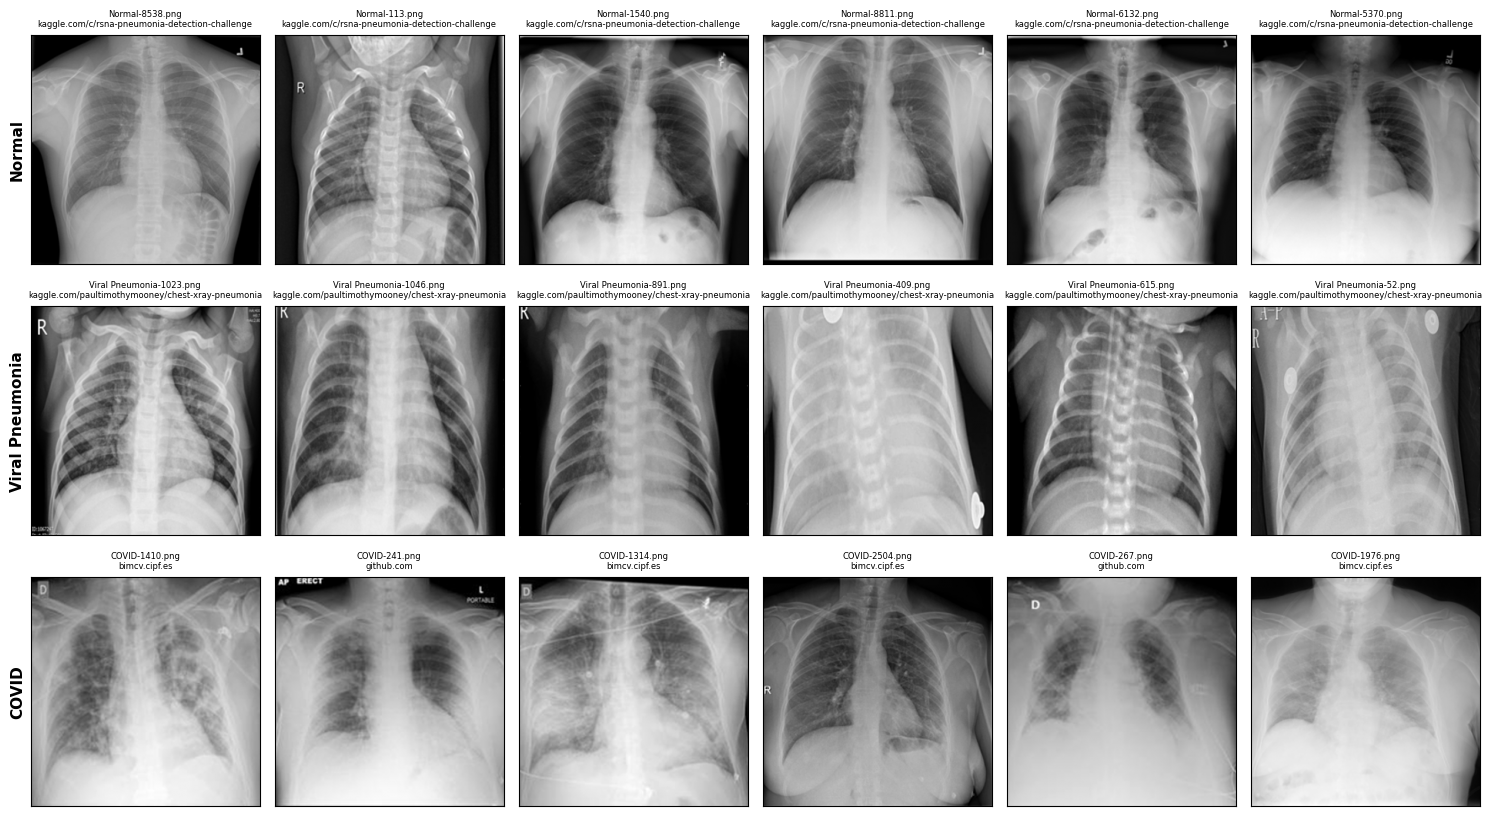

In [7]:
import matplotlib.pyplot as plt

# EDA: o que importa para o experimento e para a análise crítica
print("Imagens por classe:", imagens["classe"].value_counts().reindex(CLASSES).to_dict())
print("Tamanho (px) e modo de cor por classe:")
display(imagens.groupby("classe").agg(largura_min=("largura", "min"), largura_max=("largura", "max"),
                                       altura_min=("altura", "min"), altura_max=("altura", "max"),
                                       modos=("modo", lambda m: dict(Counter(m)))).reindex(CLASSES))

# Fonte × classe: se cada classe vem de uma origem diferente, o classificador pode aprender a ORIGEM
# (hospital, equipamento, faixa etária) em vez da doença (shortcut learning)
fonte_classe = pd.crosstab(imagens["fonte"], imagens["classe"])[CLASSES]
display(fonte_classe)
fonte_classe.to_csv(DIR_REPORT_ASSETS / "fonte_por_classe.csv")

# Imagens RGB: os 3 canais são iguais (cinza gravado em RGB) ou há tonalidade (mais uma pista de fonte)?
import numpy as np
rgb = imagens[imagens["modo"] == "RGB"]
if len(rgb):
    dif = [int(np.abs(np.diff(np.asarray(carregar_imagem(c, "RGB"), dtype=int), axis=2)).max()) for c in rgb["caminho"]]
    print(f"Imagens RGB: {len(rgb)} ({dict(Counter(rgb['classe']))}); diferença máxima entre canais: "
          f"0 em {sum(d == 0 for d in dif)}, > 0 em {sum(d > 0 for d in dif)} (máx. {max(dif)})")

fig, ax = plt.subplots(figsize=(7, 3))
imagens["classe"].value_counts().reindex(CLASSES).plot.bar(ax=ax)
ax.set(title="Imagens por classe (dataset inteiro)", xlabel="", ylabel="imagens")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "imagens_por_classe.png", dpi=150)
plt.show()

# 6 exemplos sorteados por classe, com a fonte
N_EXEMPLOS = 6
exemplos = imagens.groupby("classe").sample(n=N_EXEMPLOS, random_state=SEED)
fig, eixos = plt.subplots(len(CLASSES), N_EXEMPLOS, figsize=(2.5 * N_EXEMPLOS, 2.8 * len(CLASSES)))
for i, classe in enumerate(CLASSES):
    for k, (_, r) in enumerate(exemplos[exemplos["classe"] == classe].iterrows()):
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]), cmap="gray")
        ax.set_title(f"{r['arquivo']}\n{r['fonte']}", fontsize=6)
        ax.set_xticks([]); ax.set_yticks([])
    eixos[i, 0].set_ylabel(classe, fontsize=11, fontweight="bold")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "exemplos_por_classe.png", dpi=110)
plt.show()

## Quase-duplicatas e vazamento por paciente

[O md5 só pega cópias idênticas; a base não tem ID de paciente e há séries do mesmo paciente (nomes
consecutivos). Critério pela correlação dos pixels (64×64), fixado por inspeção visual antes do treino;
quantas imagens saíram; limitação: sem ID, o split por paciente não é garantido.]

In [8]:
import torch

from src.dados import vetores_pixels

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)

# Vetores de pixels de TODAS as imagens (64×64, centrados, norma 1): o produto interno é a correlação dos
# pixels, perto de 1 só para a mesma foto. Features do ImageNet não servem aqui: em raio-X, pacientes
# diferentes já ficam com cosseno ~0,98 e os grupos se encadeiam. Nada é ajustado nos dados: sem vazamento.
imagens = imagens.reset_index(drop=True)
_t0 = time.perf_counter()
FEATS = vetores_pixels(imagens["caminho"].tolist())
TEMPOS.append({"etapa": "vetores de pixels (quase-duplicatas)", "segundos": round(time.perf_counter() - _t0, 1)})
print(f"Vetores: {tuple(FEATS.shape)} em {TEMPOS[-1]['segundos']} s")

# Pares com cosseno alto, em blocos (a matriz inteira 15 mil × 15 mil não cabe com folga na RAM)
LIMIAR_INSPECAO = 0.95
feats_dev = FEATS.to(DEVICE)
vizinho = torch.empty(len(FEATS))
pares = []
for ini in range(0, len(FEATS), 2048):
    sim = feats_dev[ini:ini + 2048] @ feats_dev.T
    sim[torch.arange(sim.shape[0], device=sim.device), torch.arange(ini, ini + sim.shape[0], device=sim.device)] = -1   # tira a própria imagem
    vizinho[ini:ini + sim.shape[0]] = sim.max(dim=1).values.cpu()
    a, b = torch.nonzero(sim >= LIMIAR_INSPECAO, as_tuple=True)
    a = a + ini
    manter = a < b                                                       # cada par uma vez
    pares += list(zip(a[manter].tolist(), b[manter].tolist(), sim[a[manter] - ini, b[manter]].tolist()))
del feats_dev

PARES = pd.DataFrame(pares, columns=["a", "b", "cosseno"])
PARES["classe_a"] = imagens["classe"].values[PARES["a"]]
PARES["classe_b"] = imagens["classe"].values[PARES["b"]]
PARES["arquivo_a"] = imagens["arquivo"].values[PARES["a"]]
PARES["arquivo_b"] = imagens["arquivo"].values[PARES["b"]]
PARES = PARES.sort_values("cosseno", ascending=False).reset_index(drop=True)
print("Correlação com o vizinho mais próximo, por classe (P50 / P90 / P99):")
for classe in CLASSES:
    v = vizinho[torch.tensor((imagens["classe"] == classe).to_numpy())].numpy()
    print(f"  {classe}: {np.percentile(v, 50):.3f} / {np.percentile(v, 90):.3f} / {np.percentile(v, 99):.3f}")
for faixa in (0.99, 0.98, 0.97, 0.96, 0.95):
    sel = PARES[PARES["cosseno"] >= faixa]
    print(f"Pares com correlação >= {faixa}: {len(sel)} (mesma classe {int((sel['classe_a'] == sel['classe_b']).sum())}, "
          f"entre classes {int((sel['classe_a'] != sel['classe_b']).sum())})")

Dispositivo: cuda
Vetores: (15099, 4096) em 39.5 s
Correlação com o vizinho mais próximo, por classe (P50 / P90 / P99):
  Normal: 0.918 / 0.946 / 0.962
  Viral Pneumonia: 0.917 / 0.953 / 0.962
  COVID: 0.898 / 0.993 / 1.000
Pares com correlação >= 0.99: 259 (mesma classe 259, entre classes 0)
Pares com correlação >= 0.98: 275 (mesma classe 275, entre classes 0)
Pares com correlação >= 0.97: 308 (mesma classe 308, entre classes 0)
Pares com correlação >= 0.96: 424 (mesma classe 423, entre classes 1)
Pares com correlação >= 0.95: 1149 (mesma classe 1112, entre classes 37)


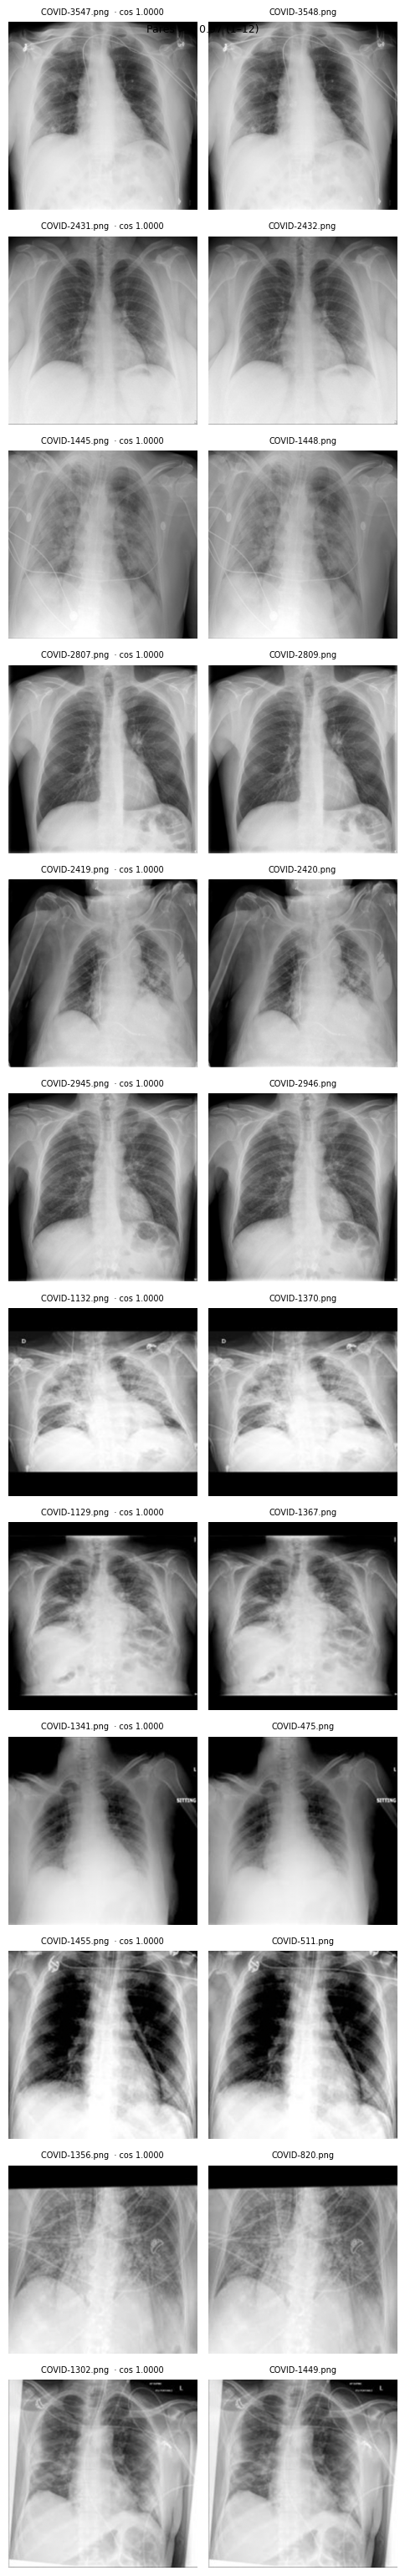

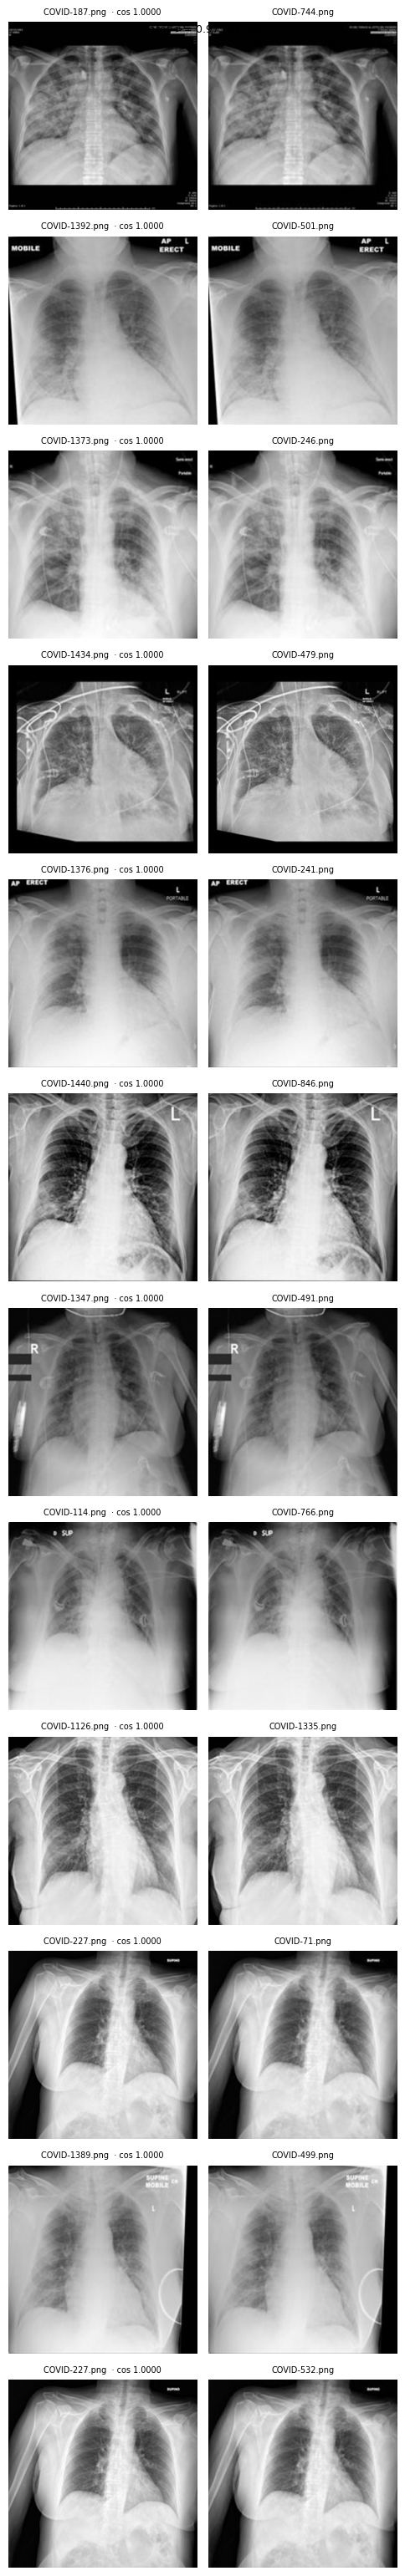

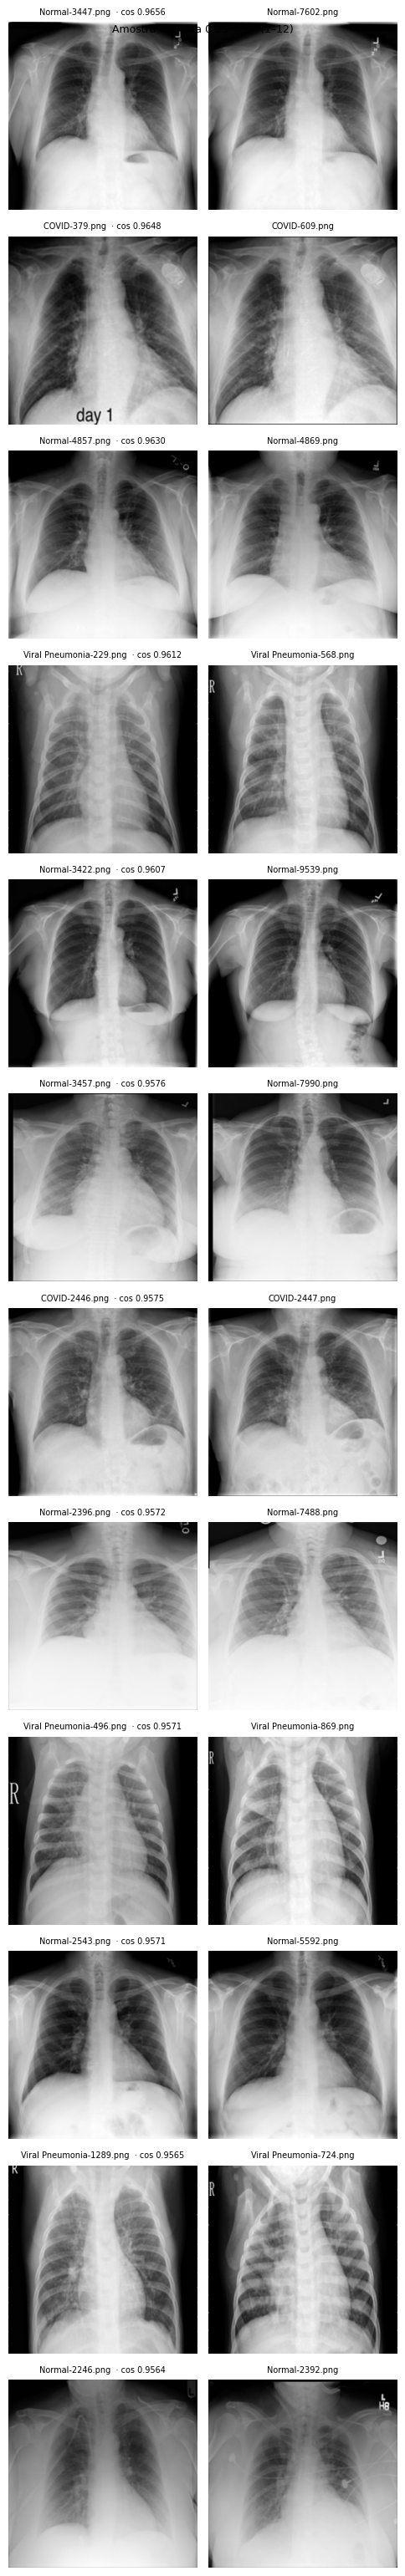

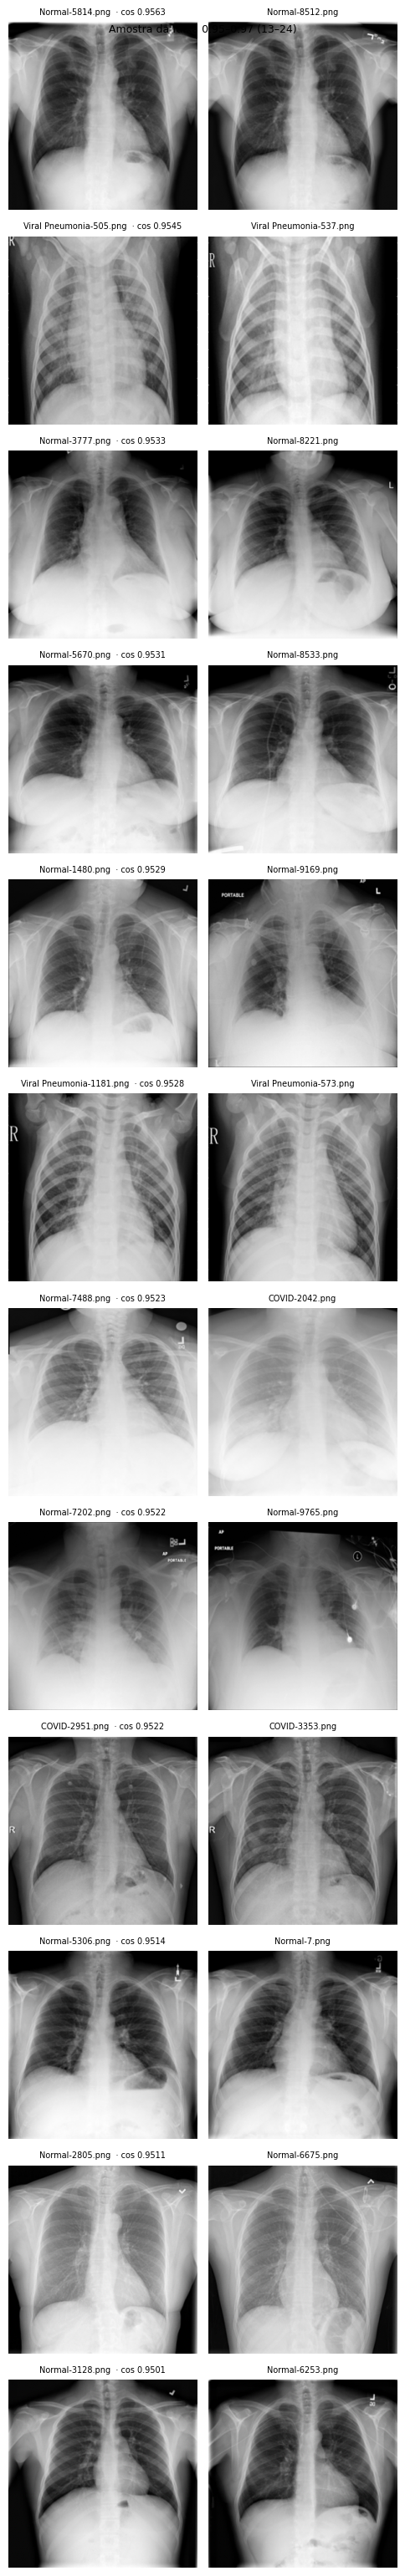

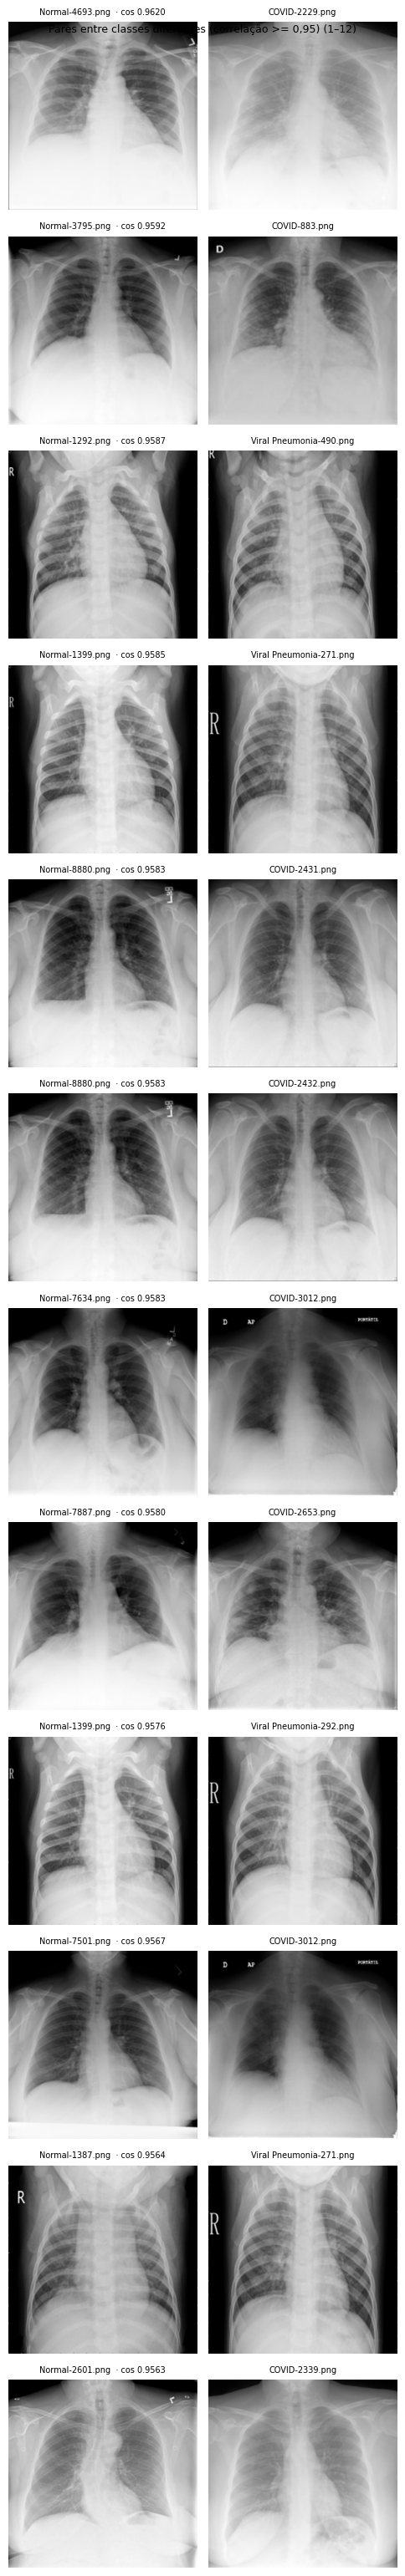

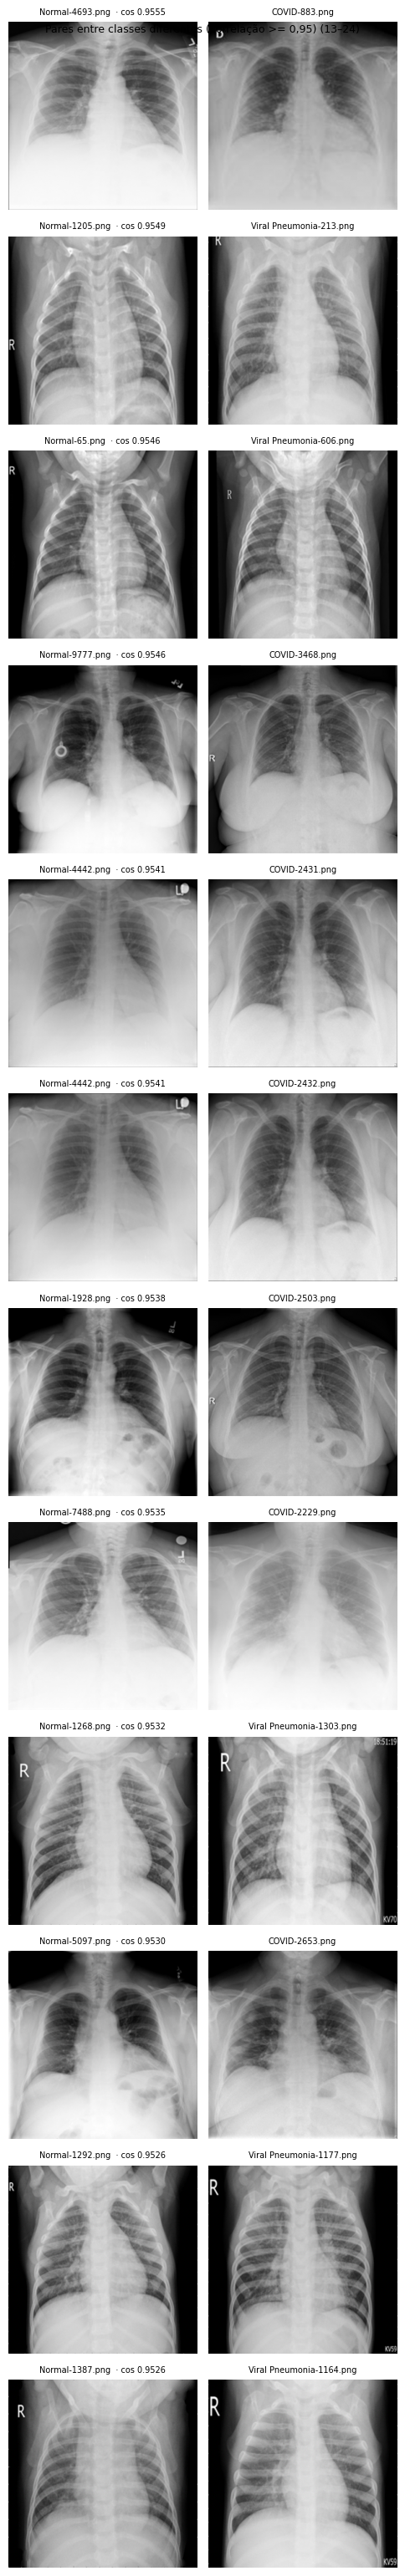

In [9]:
def mostrar_pares(pares, titulo, arquivo, n=24, por_figura=12):
    """Pares lado a lado (no máximo n), em figuras de até `por_figura` pares."""
    pares = pares.head(n)
    for ini in range(0, len(pares), por_figura):
        bloco = pares.iloc[ini:ini + por_figura]
        fig, eixos = plt.subplots(len(bloco), 2, figsize=(5, 2.6 * len(bloco)), squeeze=False)
        for linha, (_, r) in enumerate(bloco.iterrows()):
            for coluna, (idx, nome) in enumerate(((r["a"], r["arquivo_a"]), (r["b"], r["arquivo_b"]))):
                eixos[linha, coluna].imshow(carregar_imagem(imagens.loc[idx, "caminho"]), cmap="gray")
                eixos[linha, coluna].set_title(nome + (f"  · cos {r['cosseno']:.4f}" if coluna == 0 else ""), fontsize=7)
                eixos[linha, coluna].axis("off")
        fig.suptitle(f"{titulo} ({ini + 1}–{ini + len(bloco)})", fontsize=9)
        plt.tight_layout()
        fig.savefig(DIR_REPORT_ASSETS / f"{arquivo}_{ini // por_figura + 1}.png", dpi=90)
        plt.show()


# Evidência para fixar o limiar: os pares mais altos e uma amostra da faixa logo abaixo do limiar
mostrar_pares(PARES[PARES["cosseno"] >= LIMIAR_QUASE_DUPLICATA], f"Pares >= {LIMIAR_QUASE_DUPLICATA}", "qdup_acima")
faixa = PARES[(PARES["cosseno"] >= LIMIAR_QUASE_DUPLICATA - 0.02) & (PARES["cosseno"] < LIMIAR_QUASE_DUPLICATA)]
mostrar_pares(faixa.sample(n=min(24, len(faixa)), random_state=SEED).sort_values("cosseno", ascending=False),
              f"Amostra da faixa {LIMIAR_QUASE_DUPLICATA - 0.02:.2f}–{LIMIAR_QUASE_DUPLICATA}", "qdup_faixa")
mostrar_pares(PARES[PARES["classe_a"] != PARES["classe_b"]], "Pares entre classes diferentes (correlação >= 0,95)", "qdup_entre_classes")

In [10]:
# Deduplicação antes do split: pares com cosseno >= LIMIAR_QUASE_DUPLICATA viram grupos (componentes
# conexos). Grupo com uma classe só: fica uma imagem (a primeira em ordem alfabética). Grupo com classes
# diferentes: conflito de rótulo, saem todas.
ligacoes = PARES[PARES["cosseno"] >= LIMIAR_QUASE_DUPLICATA]
pai = list(range(len(imagens)))


def raiz(i):
    while pai[i] != i:
        pai[i] = pai[pai[i]]
        i = pai[i]
    return i


for a, b in zip(ligacoes["a"], ligacoes["b"]):
    pai[raiz(a)] = raiz(b)
imagens["grupo_dup"] = [raiz(i) for i in range(len(imagens))]
tamanhos = imagens["grupo_dup"].value_counts()
grupos = tamanhos[tamanhos > 1]
# Trava contra encadeamento: um grupo enorme indica limiar baixo demais (A~B, B~C... juntam pacientes diferentes)
assert tamanhos.max() <= 20, f"grupo com {tamanhos.max()} imagens: limiar baixo demais, revise LIMIAR_QUASE_DUPLICATA"
classes_por_grupo = imagens.groupby("grupo_dup")["classe"].nunique()
conflito = imagens["grupo_dup"].isin(classes_por_grupo[classes_por_grupo > 1].index)
print(f"Limiar {LIMIAR_QUASE_DUPLICATA}: {len(ligacoes)} pares -> {len(grupos)} grupos "
      f"(tamanhos: {dict((int(t), int(n)) for t, n in grupos.value_counts().sort_index().items())}); "
      f"imagens em grupos com classes diferentes: {int(conflito.sum())}")

manter = imagens[~conflito].sort_values("caminho_rel").drop_duplicates("grupo_dup", keep="first").index.sort_values()
removidas = imagens.drop(index=manter)
print(f"Removidas: {len(removidas)} · por classe: {removidas['classe'].value_counts().reindex(CLASSES, fill_value=0).to_dict()}")
removidas[["caminho_rel", "classe", "fonte"]].to_csv(DIR_REPORT_ASSETS / "quase_duplicatas_removidas.csv", index=False)
imagens = imagens.loc[manter].reset_index(drop=True)
print("Imagens por classe após a deduplicação:", imagens["classe"].value_counts().reindex(CLASSES).to_dict())

Limiar 0.97: 308 pares -> 188 grupos (tamanhos: {2: 143, 3: 35, 4: 9, 6: 1}); imagens em grupos com classes diferentes: 0
Removidas: 245 · por classe: {'Normal': 12, 'Viral Pneumonia': 0, 'COVID': 233}
Imagens por classe após a deduplicação: {'Normal': 10179, 'Viral Pneumonia': 1338, 'COVID': 3337}


**Desenho do split.** [Escassez do legado só no treino (840/240/120); validação e teste reais e maiores,
do restante do dataset; por que o teste precisa ser maior (recall de COVID mensurável); sem
sobreposição entre splits.]

In [ ]:
from src.dados import SPLIT_TESTE, SPLIT_TREINO, SPLIT_VALIDACAO, dividir_com_escassez

# Split com escassez só no treino: teste e validação sorteados primeiro (quantidades fixas por classe),
# treino do restante. As imagens que sobram não são usadas.
imagens = dividir_com_escassez(imagens, N_TREINO, N_VALIDACAO, N_TESTE, SEED)
# Teste confirmatório: mesmas quantidades do teste, sorteado (outra seed) só entre as imagens não usadas
SPLIT_TESTE_CONF = "teste_confirmatorio"
restantes = imagens[imagens["split"].isna()]
for classe, quantos in N_TESTE.items():
    escolhidas = restantes[restantes["classe"] == classe].sample(n=quantos, random_state=SEED_TESTE_CONFIRMATORIO)
    imagens.loc[escolhidas.index, "split"] = SPLIT_TESTE_CONF
ORDEM_SPLITS = [SPLIT_TREINO, SPLIT_VALIDACAO, SPLIT_TESTE, SPLIT_TESTE_CONF]
usadas = imagens[imagens["split"].notna()].reset_index(drop=True)

# Sem vazamento: nenhum conteúdo (md5) em mais de um split
assert (usadas.groupby("md5")["split"].nunique() == 1).all(), "Mesma imagem em mais de um split"
tabela_split = pd.crosstab(usadas["classe"], usadas["split"]).reindex(CLASSES)[ORDEM_SPLITS]
tabela_split.loc["total"] = tabela_split.sum()
display(tabela_split)
for s, esperado in ((SPLIT_TREINO, N_TREINO), (SPLIT_VALIDACAO, N_VALIDACAO), (SPLIT_TESTE, N_TESTE), (SPLIT_TESTE_CONF, N_TESTE)):
    assert tabela_split[s].drop("total").to_dict() == esperado, (s, tabela_split[s].to_dict())
# Composição das fontes em cada split (o sorteio é estratificado só por classe)
fonte_split = pd.crosstab([usadas["classe"], usadas["fonte"]], usadas["split"])[ORDEM_SPLITS]
display(fonte_split)
fonte_split.to_csv(DIR_REPORT_ASSETS / "fonte_por_split.csv")

# Split salvo para reprodutibilidade (como na A1 e na A3). Se a versão do repositório existir, o split
# recalculado tem que ser idêntico a ela.
COLUNAS_SPLIT = ["caminho_rel", "classe", "md5", "fonte", "split"]
usadas[COLUNAS_SPLIT].to_csv(DIR_REPORT_ASSETS / "split_imagens.csv", index=False)
SPLIT_VERSIONADO = Path(PROJECT_DIR) / "split_imagens.csv"
if SPLIT_VERSIONADO.exists():
    versionado = pd.read_csv(SPLIT_VERSIONADO)
    recalculado = usadas[COLUNAS_SPLIT].sort_values("caminho_rel").reset_index(drop=True)
    pd.testing.assert_frame_equal(recalculado, versionado.sort_values("caminho_rel").reset_index(drop=True))
    print("Split versionado confere com o recalculado.")
else:
    print(f"Split salvo em {DIR_REPORT_ASSETS / 'split_imagens.csv'} (copiar para {SUBPASTA}/ e versionar).")

### Protocolo (registrado em 06/10/2026, antes do treino da cGAN)

**Ordem real dos fatos.** As duas condições sem GAN (sem tratamento e oversampling) foram treinadas e
avaliadas uma vez no **teste original** antes de a cGAN existir (avaliação exploratória). Para que nenhuma
decisão da GAN pudesse ser influenciada por esse resultado, foi sorteado um **teste confirmatório** (mesmas
quantidades, 600/300/300, outra seed, só entre imagens não usadas) e o protocolo abaixo foi fixado antes de
treinar a GAN. Os números finais das três condições são os do teste confirmatório; os do teste original
são reportados como exploratórios.

**Fixado antes da GAN:**
- classificador: `CONFIG_CLASSIFICADOR` (ResNet-18 pré-treinada, 224 px, AdamW lr 1e-4, 12 épocas),
  seeds 0, 1, 2, seleção da época pela média dos recalls na validação; idêntico nas três condições;
- `N_SINTETICAS = 720` (já definido antes da avaliação exploratória): COVID passa de 120 para 840 nas
  condições "oversampling" (cada COVID real repetida 7 vezes) e "gan" (120 reais + 720 geradas), o que iguala
  o tamanho do treino, o número de passos e a proporção de classes;
- **comparação principal: gan × oversampling** (só muda "cópia real" para "imagem nova"); gan × sem tratamento
  mistura o efeito da GAN com o do reequilíbrio e do número de passos;
- cGAN: `CONFIG_GAN`, 200 épocas; usa-se a **versão com mitigação no checkpoint da última época**; a versão
  sem mitigação serve só para o diagnóstico (R6, R7). A GAN só vê o treino; nenhuma decisão usa a validação do
  classificador nem os testes.

## Classificador: ResNet-18 pré-treinada (R8)

[Por que a versão corrigida (pré-treinada) e não a do legado; entrada (tons de cinza → 3 canais,
resolução, normalização); configuração única usada nos treinos com e sem imagens geradas.]

In [ ]:
from src.classificador import recall_por_classe

# Dados de treino de cada condição (validação e teste são sempre os mesmos, só imagens reais)
treino_real = usadas[usadas["split"] == SPLIT_TREINO]
validacao = usadas[usadas["split"] == SPLIT_VALIDACAO].reset_index(drop=True)
teste = usadas[usadas["split"] == SPLIT_TESTE].reset_index(drop=True)
teste_conf = usadas[usadas["split"] == SPLIT_TESTE_CONF].reset_index(drop=True)
COVID = CLASSES.index("COVID")
DIR_SINTETICAS = DIR_OUTPUTS / "sinteticas_covid"   # preenchida pela seção da cGAN


def dados_treino(condicao: str, seed: int):
    """(caminhos, rótulos) do treino da condição."""
    caminhos = treino_real["caminho"].tolist()
    rotulos = [CLASSES.index(c) for c in treino_real["classe"]]
    covid_real = treino_real.loc[treino_real["classe"] == "COVID", "caminho"].tolist()
    if condicao == "oversampling":
        # cada COVID real repetida N_SINTETICAS / 120 vezes a mais (determinístico: todas com o mesmo peso)
        assert N_SINTETICAS % len(covid_real) == 0, (N_SINTETICAS, len(covid_real))
        extras = covid_real * (N_SINTETICAS // len(covid_real))
    elif condicao == "gan":
        extras = sorted(str(p) for p in DIR_SINTETICAS.glob("*.png"))
        assert len(extras) == N_SINTETICAS, f"esperadas {N_SINTETICAS} imagens sintéticas, há {len(extras)}"
    else:
        assert condicao == "sem_tratamento", condicao
        extras = []
    return caminhos + extras, rotulos + [COVID] * len(extras)


for condicao in ("sem_tratamento", "oversampling"):
    c, r = dados_treino(condicao, 0)
    print(f"{condicao}: {len(c)} imagens de treino, por classe {dict(Counter(CLASSES[k] for k in r))}")

In [ ]:
import json

from src.classificador import treinar_classificador

DIR_EXPERIMENTOS = DIR_OUTPUTS / "experimentos"
DIR_EXPERIMENTOS.mkdir(parents=True, exist_ok=True)
y_val = [CLASSES.index(c) for c in validacao["classe"]]


def rodar_condicao(condicao: str):
    """Treina a condição para cada seed e salva, por imagem, as probabilidades na validação e no teste.

    A configuração é a mesma em todas as condições (CONFIG_CLASSIFICADOR); só os dados de treino mudam.
    Se o arquivo da condição já existe, só carrega (não treina de novo).
    """
    arquivo = DIR_EXPERIMENTOS / f"predicoes_{VERSAO_PREDICOES}_{condicao}.csv"
    arquivo_config = arquivo.with_suffix(".json")
    config_atual = {"classificador": CONFIG_CLASSIFICADOR, "seeds": SEEDS_CLASSIFICADOR, "n_sinteticas": N_SINTETICAS}
    if arquivo.exists():
        assert json.loads(arquivo_config.read_text()) == json.loads(json.dumps(config_atual)), "configuração mudou"
        print(f"{condicao}: carregando {arquivo.name}")
        return pd.read_csv(arquivo)
    from src.classificador import DatasetRaioX, prever, transforms_raio_x
    from torch.utils.data import DataLoader
    _, t_aval = transforms_raio_x(CONFIG_CLASSIFICADOR["resolucao"])
    loaders = {nome: DataLoader(DatasetRaioX(df["caminho"].tolist(), [0] * len(df), t_aval),
                                batch_size=64, shuffle=False, num_workers=CONFIG_CLASSIFICADOR["num_workers"])
               for nome, df in (("validacao", validacao), ("teste", teste), (SPLIT_TESTE_CONF, teste_conf))}
    tabelas = []
    for seed in SEEDS_CLASSIFICADOR:
        if DEVICE == "cuda":
            torch.cuda.reset_peak_memory_stats()
        t0 = time.perf_counter()
        caminhos, rotulos = dados_treino(condicao, seed)
        modelo, hist, melhor_epoca = treinar_classificador(caminhos, rotulos, validacao["caminho"].tolist(), y_val,
                                                            CONFIG_CLASSIFICADOR, seed, DEVICE, len(CLASSES))
        hist.to_csv(DIR_EXPERIMENTOS / f"historico_{condicao}_seed{seed}.csv", index=False)
        for nome, df in (("validacao", validacao), ("teste", teste), (SPLIT_TESTE_CONF, teste_conf)):
            probs = prever(modelo, loaders[nome], DEVICE)
            t = df[["caminho_rel", "classe", "fonte"]].copy()
            t["condicao"], t["seed"], t["split"], t["melhor_epoca"] = condicao, seed, nome, melhor_epoca
            t["pred"] = [CLASSES[k] for k in probs.argmax(1)]
            for k, classe in enumerate(CLASSES):
                t[f"prob_{classe}"] = probs[:, k]
            tabelas.append(t)
        TEMPOS.append({"etapa": f"classificador {condicao} seed {seed}", "segundos": round(time.perf_counter() - t0, 1),
                       **({"pico_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2)} if DEVICE == "cuda" else {})})
        print(f"{condicao} seed {seed}: melhor época {melhor_epoca}, {TEMPOS[-1]['segundos']} s")
        del modelo
    saida = pd.concat(tabelas, ignore_index=True)
    saida.to_csv(arquivo, index=False)
    arquivo_config.write_text(json.dumps(config_atual))
    return saida


def resumo(predicoes: pd.DataFrame, split: str = "teste") -> pd.DataFrame:
    """Recall por classe (média ± desvio entre seeds) de cada condição."""
    linhas = []
    for (condicao, seed), g in predicoes[predicoes["split"] == split].groupby(["condicao", "seed"]):
        rec = recall_por_classe(g["classe"].map(CLASSES.index).to_numpy(), g["pred"].map(CLASSES.index).to_numpy(), len(CLASSES))
        linhas.append({"condicao": condicao, "seed": seed, **{f"recall_{c}": r for c, r in zip(CLASSES, rec)},
                       "recall_medio": np.nanmean(rec), "accuracy": (g["classe"] == g["pred"]).mean()})
    por_seed = pd.DataFrame(linhas)
    return por_seed.groupby("condicao").agg(["mean", "std"]).drop(columns="seed").round(4)

In [14]:
# Treinos SEM imagens geradas (R8): a condição do legado (sem tratamento) e o controle (oversampling real)
PREDICOES = pd.concat([rodar_condicao("sem_tratamento"), rodar_condicao("oversampling")], ignore_index=True)
print("Validação:"); display(resumo(PREDICOES, "validacao"))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


sem_tratamento seed 0: melhor época 3, 101.8 s
sem_tratamento seed 1: melhor época 2, 98.2 s
sem_tratamento seed 2: melhor época 7, 99.0 s
oversampling seed 0: melhor época 9, 137.5 s
oversampling seed 1: melhor época 9, 137.1 s
oversampling seed 2: melhor época 9, 136.6 s
Validação:


recall_Normal         recall_Viral Pneumonia          \
                        mean     std                   mean     std   
condicao                                                              
oversampling          0.9756  0.0139                 0.9667  0.0267   
sem_tratamento        0.9578  0.0195                 0.9311  0.0154   

               recall_COVID         recall_medio         accuracy          
                       mean     std         mean     std     mean     std  
condicao                                                                   
oversampling         0.9156  0.0038       0.9526  0.0056   0.9583  0.0017  
sem_tratamento       0.9267  0.0291       0.9385  0.0067   0.9433  0.0073

In [ ]:
# Só VALIDAÇÃO: que época a accuracy (critério do legado) teria escolhido, e com que recall de COVID?
# Comparado ao critério usado (média dos recalls por classe).
pesos_val = np.array([N_VALIDACAO[c] for c in CLASSES]) / sum(N_VALIDACAO.values())
linhas_ep = []
for cond in ("sem_tratamento", "oversampling"):
    for seed in SEEDS_CLASSIFICADOR:
        h = pd.read_csv(DIR_EXPERIMENTOS / f"historico_{cond}_seed{seed}.csv")
        rec = h[[f"val_recall_{k}" for k in range(len(CLASSES))]].to_numpy()
        acc = rec @ pesos_val
        e_acc, e_rec = int(acc.argmax()), int(rec.mean(axis=1).argmax())
        linhas_ep.append({"condicao": cond, "seed": seed, "epoca_pela_accuracy": e_acc + 1, "recall_covid_nessa_epoca": rec[e_acc, -1],
                          "epoca_pelo_recall_medio": e_rec + 1, "recall_covid_nessa_epoca_": rec[e_rec, -1]})
display(pd.DataFrame(linhas_ep).round(3))

## cGAN para gerar raio-X de COVID-19 (R3, R4)

[Por que cGAN (e não CycleGAN); arquitetura (DCGAN condicional), resolução, dados de treino da GAN
(só o treino), custo na T4.]

In [ ]:
from src.dados import vetores_pixels
from src.gan import Discriminador, Gerador, diversidade, gerar, nitidez, treinar_cgan, vetores_de_tensores

DIR_GAN = DIR_OUTPUTS / "gan"
DIR_GAN.mkdir(parents=True, exist_ok=True)
n_g = sum(p.numel() for p in Gerador(len(CLASSES), CONFIG_GAN["dim_z"], CONFIG_GAN["base"]).parameters())
n_d = sum(p.numel() for p in Discriminador(len(CLASSES), CONFIG_GAN["base"]).parameters())
print(f"Gerador: {n_g / 1e6:.1f} M parâmetros · Discriminador: {n_d / 1e6:.1f} M · saída {CONFIG_GAN['lado']}×{CONFIG_GAN['lado']}")

# A GAN só vê o TREINO (840/240/120), condicionada na classe; amostragem balanceada por classe
caminhos_gan = treino_real["caminho"].tolist()
rotulos_gan = [CLASSES.index(c) for c in treino_real["classe"]]

# Referências reais para o diagnóstico (todas fora dos testes): vetores de pixels das COVID do treino e da
# validação; "imagem nova de verdade" = correlação máxima de cada COVID da validação com as do treino
V_COVID_TREINO = vetores_pixels(treino_real.loc[treino_real["classe"] == "COVID", "caminho"].tolist())
V_COVID_VAL = vetores_pixels(validacao.loc[validacao["classe"] == "COVID", "caminho"].tolist())
REF_MEMORIZACAO = (V_COVID_VAL @ V_COVID_TREINO.T).max(dim=1).values
REF_DIVERSIDADE = diversidade(V_COVID_TREINO)
print(f"Referência real: correlação máx. validação→treino (COVID) P50 {REF_MEMORIZACAO.median():.3f}, "
      f"P95 {REF_MEMORIZACAO.quantile(0.95):.3f}; diversidade (correlação média entre pares) do treino {REF_DIVERSIDADE:.3f}")

### Training loop adversarial (R5)

[Perdas, alternância D/G, otimizadores, o que é monitorado.]

In [ ]:
import pickle

# Treino das duas versões (mesma seed, mesmo número de épocas). Monitoramento a cada N épocas, só com o treino:
# diversidade das COVID geradas e correlação máxima com o treino (memorização).
amostras_por_epoca = {}


def monitor(nome):
    def _f(G, epoca):
        if epoca % CONFIG_GAN["monitorar_a_cada"] and epoca != CONFIG_GAN["epocas"]:
            return None
        imgs = gerar(G, CLASSES.index("COVID"), 64, CONFIG_GAN["dim_z"], seed=123, device=DEVICE)
        v = vetores_de_tensores(imgs)
        amostras_por_epoca[(nome, epoca)] = imgs[:8]
        return {"diversidade_covid": diversidade(v), "memorizacao_p50": float((v @ V_COVID_TREINO.T).max(dim=1).values.median())}
    return _f


GANS, HIST_GAN = {}, {}
for nome, mitigacao in (("sem_mitigacao", False), ("com_mitigacao", True)):
    arquivo = DIR_GAN / f"G_{nome}.pt"
    if arquivo.exists():   # já treinada nesta sessão/pasta: carrega
        G = Gerador(len(CLASSES), CONFIG_GAN["dim_z"], CONFIG_GAN["base"]).to(DEVICE)
        G.load_state_dict(torch.load(arquivo, map_location=DEVICE))
        HIST_GAN[nome] = pd.read_csv(DIR_GAN / f"historico_{nome}.csv")
        amostras_por_epoca.update(pickle.loads((DIR_GAN / f"amostras_{nome}.pkl").read_bytes()))
        print(f"{nome}: carregado")
    else:
        if DEVICE == "cuda":
            torch.cuda.reset_peak_memory_stats()
        t0 = time.perf_counter()
        G, _, hist = treinar_cgan(caminhos_gan, rotulos_gan, len(CLASSES), CONFIG_GAN, mitigacao, SEED_GAN, DEVICE, monitor(nome))
        HIST_GAN[nome] = pd.DataFrame(hist)
        HIST_GAN[nome].to_csv(DIR_GAN / f"historico_{nome}.csv", index=False)
        torch.save(G.state_dict(), arquivo)
        (DIR_GAN / f"amostras_{nome}.pkl").write_bytes(pickle.dumps({k: v for k, v in amostras_por_epoca.items() if k[0] == nome}))
        TEMPOS.append({"etapa": f"cGAN {nome}", "segundos": round(time.perf_counter() - t0, 1),
                       **({"pico_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2)} if DEVICE == "cuda" else {})})
        print(f"{nome}: {CONFIG_GAN['epocas']} épocas em {TEMPOS[-1]['segundos']} s")
    GANS[nome] = G
    display(HIST_GAN[nome].dropna(subset=["diversidade_covid"]).round(4))

### Instabilidade: diagnóstico e mitigação (R6, R7)

[Sinais de mode collapse ou divergência na 1ª versão; estratégia de mitigação (ex.: label smoothing,
spectral norm, TTUR) e evidência de melhoria.]

In [ ]:
# Diagnóstico de instabilidade (R6) e evidência da mitigação (R7): curvas de perda, D(x) e D(G(z)), e a
# diversidade das COVID geradas ao longo do treino (colapso de modo -> correlação média entre geradas sobe
# para perto de 1; referência: a diversidade das COVID reais do treino).
fig, eixos = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for linha, nome in enumerate(("sem_mitigacao", "com_mitigacao")):
    h = HIST_GAN[nome]
    eixos[linha, 0].plot(h["epoca"], h["loss_d"], label="D"); eixos[linha, 0].plot(h["epoca"], h["loss_g"], label="G")
    eixos[linha, 0].set(title=f"{nome}: perdas", ylabel="BCE"); eixos[linha, 0].legend()
    eixos[linha, 1].plot(h["epoca"], h["d_real"], label="D(x) real"); eixos[linha, 1].plot(h["epoca"], h["d_falso"], label="D(G(z))")
    eixos[linha, 1].set(title=f"{nome}: saídas do D", ylim=(0, 1)); eixos[linha, 1].legend()
    m = h.dropna(subset=["diversidade_covid"])
    eixos[linha, 2].plot(m["epoca"], m["diversidade_covid"], "o-", label="geradas (COVID)")
    eixos[linha, 2].axhline(REF_DIVERSIDADE, color="k", ls="--", label="reais do treino")
    eixos[linha, 2].set(title=f"{nome}: correlação média entre pares", ylim=(0, 1)); eixos[linha, 2].legend()
for ax in eixos[1]:
    ax.set_xlabel("época")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "gan_diagnostico.png", dpi=120)
plt.show()

# Amostras de COVID ao longo do treino (mesmo z em todas as épocas)
for nome in ("sem_mitigacao", "com_mitigacao"):
    epocas = sorted(e for (n, e) in amostras_por_epoca if n == nome)
    fig, eixos = plt.subplots(len(epocas), 8, figsize=(12, 1.6 * len(epocas)), squeeze=False)
    for i, e in enumerate(epocas):
        for j, img in enumerate(amostras_por_epoca[(nome, e)]):
            eixos[i, j].imshow(img[0], cmap="gray", vmin=0, vmax=1); eixos[i, j].axis("off")
        eixos[i, 0].set_title(f"época {e}", fontsize=8, loc="left")
    fig.suptitle(f"{nome}: COVID geradas (mesmo z)", fontsize=10)
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / f"gan_amostras_{nome}.png", dpi=100)
    plt.show()

In [ ]:
from PIL import Image as PILImage

# Imagens sintéticas para a condição "gan": versão COM mitigação, checkpoint da última época (regra fixada antes)
G_final = GANS["com_mitigacao"]
SINTETICAS = gerar(G_final, CLASSES.index("COVID"), N_SINTETICAS, CONFIG_GAN["dim_z"], seed=SEED_GAN + 1000, device=DEVICE)
DIR_SINTETICAS.mkdir(parents=True, exist_ok=True)
for antigo in DIR_SINTETICAS.glob("*.png"):
    antigo.unlink()
for i, img in enumerate(SINTETICAS):
    PILImage.fromarray((img[0].numpy() * 255).round().astype("uint8"), mode="L").save(DIR_SINTETICAS / f"covid_sintetica_{i:04d}.png")
print(f"{len(list(DIR_SINTETICAS.glob('*.png')))} sintéticas salvas em {DIR_SINTETICAS}")

# Qualidade: memorização (correlação máxima com as COVID do treino) × referência real (validação -> treino),
# diversidade × reais do treino, e nitidez (as sintéticas, 128 px, são ampliadas para 224 no classificador)
v_sint = vetores_de_tensores(SINTETICAS)
mem = (v_sint @ V_COVID_TREINO.T).max(dim=1)
print(f"Correlação máx. sintética→treino: P50 {mem.values.median():.3f}, P95 {mem.values.quantile(0.95):.3f} "
      f"(referência real validação→treino: P50 {REF_MEMORIZACAO.median():.3f}, P95 {REF_MEMORIZACAO.quantile(0.95):.3f}); "
      f">= {LIMIAR_QUASE_DUPLICATA} (mesma foto): {int((mem.values >= LIMIAR_QUASE_DUPLICATA).sum())} de {len(v_sint)}")
print(f"Diversidade (correlação média entre pares): sintéticas {diversidade(v_sint):.3f} × reais do treino {REF_DIVERSIDADE:.3f}")
reais_128 = torch.stack([torch.from_numpy(np.asarray(carregar_imagem(c, 'L').resize((128, 128)), dtype=np.float32) / 255)[None]
                         for c in treino_real.loc[treino_real["classe"] == "COVID", "caminho"]])
print(f"Nitidez (variância do laplaciano, 128 px): sintéticas {np.median(nitidez(SINTETICAS)):.4f} × reais {np.median(nitidez(reais_128)):.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(REF_MEMORIZACAO.numpy(), bins=30, alpha=0.6, density=True, label="reais da validação → treino")
ax.hist(mem.values.numpy(), bins=30, alpha=0.6, density=True, label="sintéticas → treino")
ax.axvline(LIMIAR_QUASE_DUPLICATA, color="r", ls="--", label="limiar 'mesma foto'")
ax.set(xlabel="correlação máxima com as COVID do treino", ylabel="densidade", title="Memorização da cGAN")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "gan_memorizacao.png", dpi=130)
plt.show()

# Grade: 16 sintéticas e, ao lado, as 4 mais parecidas com o treino junto com a imagem real mais próxima
fig, eixos = plt.subplots(3, 8, figsize=(14, 5.6))
for k, ax in enumerate(eixos[:2].flat):
    ax.imshow(SINTETICAS[k, 0], cmap="gray"); ax.axis("off")
treino_covid = treino_real[treino_real["classe"] == "COVID"].reset_index(drop=True)
for j, i in enumerate(mem.values.argsort(descending=True)[:4].tolist()):
    eixos[2, 2 * j].imshow(SINTETICAS[i, 0], cmap="gray"); eixos[2, 2 * j].set_title(f"sintética · {mem.values[i]:.3f}", fontsize=7)
    eixos[2, 2 * j + 1].imshow(carregar_imagem(treino_covid.loc[int(mem.indices[i]), "caminho"]), cmap="gray")
    eixos[2, 2 * j + 1].set_title("real mais próxima", fontsize=7)
for ax in eixos[2]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "gan_sinteticas.png", dpi=110)
plt.show()

## Classificador COM imagens geradas e comparação (R9, R10)

[Quantas imagens sintéticas de COVID entram no treino e por quê; mesma configuração do treino sem GAN.]

In [ ]:
# Treino COM imagens geradas (R9): mesma configuração e seeds das outras condições
PREDICOES = pd.concat([PREDICOES, rodar_condicao("gan")], ignore_index=True)
print("Validação:"); display(resumo(PREDICOES, "validacao"))

In [ ]:
import seaborn as sns
from scipy.stats import binomtest
from sklearn.metrics import confusion_matrix

# Comparação final no TESTE CONFIRMATÓRIO (nunca visto antes; ver o protocolo). O teste original, já visto
# na avaliação exploratória das condições sem GAN, é reportado à parte.
CONDICOES = ["sem_tratamento", "oversampling", "gan"]
for split, rotulo in ((SPLIT_TESTE_CONF, "TESTE CONFIRMATÓRIO (final)"), ("teste", "teste original (exploratório)")):
    print(f"Recall por classe — {rotulo}:"); display(resumo(PREDICOES, split))

tc = PREDICOES[PREDICOES["split"] == SPLIT_TESTE_CONF]
covid_tc = tc[tc["classe"] == "COVID"].assign(ok=lambda d: d["pred"] == "COVID")

# Diferença de recall de COVID entre condições (média das seeds), com IC por bootstrap das imagens
acerto = covid_tc.pivot_table(index="caminho_rel", columns=["condicao", "seed"], values="ok").astype(float)
media_cond = {c: acerto[c].mean(axis=1).to_numpy() for c in CONDICOES}
rng = np.random.default_rng(SEED)
idx_boot = rng.integers(0, len(acerto), size=(2000, len(acerto)))
for a, b in (("gan", "oversampling"), ("gan", "sem_tratamento"), ("oversampling", "sem_tratamento")):
    dif = media_cond[a] - media_cond[b]
    boot = dif[idx_boot].mean(axis=1)
    print(f"Recall de COVID {a} − {b}: {dif.mean():+.4f} (IC 95% bootstrap das imagens: {np.percentile(boot, 2.5):+.4f}; "
          f"{np.percentile(boot, 97.5):+.4f}; não inclui a variância entre seeds)")

# McNemar exato por seed (mesmas imagens): mostra quanto re-treinar muda em relação a trocar de condição
for a, b in (("gan", "oversampling"), ("gan", "sem_tratamento")):
    for seed in SEEDS_CLASSIFICADOR:
        xa, xb = acerto[(a, seed)].astype(bool), acerto[(b, seed)].astype(bool)
        so_a, so_b = int((xa & ~xb).sum()), int((~xa & xb).sum())
        p = binomtest(so_a, so_a + so_b).pvalue if so_a + so_b else 1.0
        print(f"  seed {seed}: {a} × {b}: acertos só em {a} = {so_a}, só em {b} = {so_b} (p = {p:.3f})")

print("Recall de COVID por fonte (teste confirmatório, média das seeds):")
display(covid_tc.groupby(["fonte", "condicao"])["ok"].mean().unstack().reindex(columns=CONDICOES).round(3))
pediatrico = tc[(tc["classe"] == "Normal") & tc["fonte"].str.contains("paultimothymooney")]
print(f"Normais pediátricos no teste confirmatório: {pediatrico['caminho_rel'].nunique()}; fração classificada como Viral Pneumonia:")
display(pediatrico.assign(vp=pediatrico["pred"] == "Viral Pneumonia").groupby("condicao")["vp"].mean().reindex(CONDICOES).round(3))

# Matrizes de confusão (soma das 3 seeds), teste confirmatório
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, cond in zip(eixos, CONDICOES):
    g = tc[tc["condicao"] == cond]
    sns.heatmap(confusion_matrix(g["classe"], g["pred"], labels=CLASSES), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set(title=f"{cond} (3 seeds somadas)", xlabel="predita", ylabel="real")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "matrizes_confusao.png", dpi=130)
plt.show()

# Vazamento por paciente (descritivo, nenhuma decisão depende disso): recall de COVID no teste confirmatório
# para imagens com e sem um "vizinho" no treino (correlação de pixels >= 0,95 com alguma COVID do treino)
treino_arquivos = set(treino_real["arquivo"])
com_vizinho = set()
for x, y in zip(PARES["arquivo_a"], PARES["arquivo_b"]):
    if x in treino_arquivos: com_vizinho.add(y)
    if y in treino_arquivos: com_vizinho.add(x)
arq_tc = usadas.loc[usadas["split"] == SPLIT_TESTE_CONF, ["caminho_rel", "arquivo"]]
covid_tc = covid_tc.merge(arq_tc, on="caminho_rel")
covid_tc["vizinho_no_treino"] = covid_tc["arquivo"].isin(com_vizinho)
print("Recall de COVID com e sem vizinho no treino (correlação >= 0,95), média das seeds:")
display(covid_tc.groupby(["vizinho_no_treino", "condicao"])["ok"].agg(["mean", "count"]).unstack().round(3))

**Leitura da comparação (R10).** [O que muda no recall de COVID; se a diferença é maior que a variação
entre seeds; custo em outras classes; limitações.]

## Plano de melhoria integrado (R11, R12)

[Plano que endereça todos os problemas do diagnóstico: modelo, métrica, augmentation sintética e
critério de adoção clínica.]

## 4.2 — Estudo de caso: classificação de fluxo de tráfego (R13–R16)

[≥ 4 problemas técnicos/metodológicos; impactos em produção (chuva, noite, ângulos); riscos do transfer
learning de ImageNet para fluxo de tráfego; abordagem proposta para cada problema.]

## Apêndice: versões e tempo/memória (R17)

In [21]:
# [versões das bibliotecas e resumo de tempo e memória, como na A3]